<a href="https://colab.research.google.com/github/Manushprajwal7/AI-Driven-Cloud-Load-Balancer/blob/main/DL_%2B_CNN_V4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# STEP 1 — ENVIRONMENT SETUP
# =========================================================

# ---------------------------------------------------------
# INSTALL REQUIRED LIBRARIES
# ---------------------------------------------------------

!pip install -q kagglehub

# ---------------------------------------------------------
# IMPORTS
# ---------------------------------------------------------

import os
import random
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

from glob import glob

# ---------------------------------------------------------
# RANDOM SEEDS
# ---------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------------------------------------------------
# GPU CHECK
# ---------------------------------------------------------

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU DETECTED:")
    for gpu in gpus:
        print(gpu)
else:
    print("NO GPU DETECTED")

print("\nTensorFlow Version:", tf.__version__)

# =========================================================
# DOWNLOAD DATASET
# =========================================================

import kagglehub

dataset_path = kagglehub.dataset_download(
    "balraj98/deepglobe-land-cover-classification-dataset"
)

print("\nDATASET DOWNLOADED")

print("\nDataset Path:")
print(dataset_path)

# =========================================================
# DATASET PATHS
# =========================================================

TRAIN_DIR = os.path.join(dataset_path, "train")

CLASS_CSV = os.path.join(dataset_path, "class_dict.csv")

print("\nTRAIN DIRECTORY EXISTS:",
      os.path.exists(TRAIN_DIR))

print("CLASS CSV EXISTS:",
      os.path.exists(CLASS_CSV))

# =========================================================
# LOAD IMAGE PATHS
# =========================================================

all_sat_images = sorted(
    glob(os.path.join(TRAIN_DIR, "*_sat.jpg"))
)

print("\nTOTAL SATELLITE IMAGES:",
      len(all_sat_images))

print("\nSAMPLE IMAGE:")
print(all_sat_images[0])

GPU DETECTED:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

TensorFlow Version: 2.20.0
Using Colab cache for faster access to the 'deepglobe-land-cover-classification-dataset' dataset.

DATASET DOWNLOADED

Dataset Path:
/kaggle/input/deepglobe-land-cover-classification-dataset

TRAIN DIRECTORY EXISTS: True
CLASS CSV EXISTS: True

TOTAL SATELLITE IMAGES: 803

SAMPLE IMAGE:
/kaggle/input/deepglobe-land-cover-classification-dataset/train/100694_sat.jpg


In [ ]:
# =========================================================
# STEP 1 — MOUNT GOOGLE DRIVE
# =========================================================

from google.colab import drive

drive.mount('/content/drive')

print("GOOGLE DRIVE MOUNTED")

Mounted at /content/drive
GOOGLE DRIVE MOUNTED


CLASS NAMES:

0 -> urban_land
1 -> agriculture_land
2 -> rangeland
3 -> forest_land
4 -> water
5 -> barren_land
6 -> unknown

DOMINANT CLASS ID: 1
DOMINANT CLASS NAME: agriculture_land


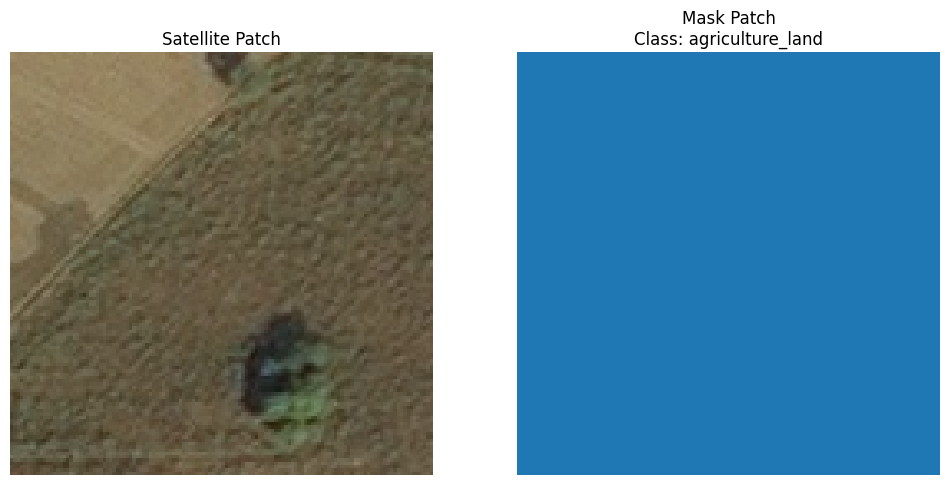

In [ ]:
# =========================================================
# STEP 2 — DOMINANT-CLASS PATCH GENERATION
# =========================================================

# ---------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------

PATCH_SIZE = 128

# =========================================================
# CLASS DEFINITIONS
# =========================================================

class_df = pd.read_csv(CLASS_CSV)

CLASS_NAMES = class_df['name'].tolist()

CLASS_RGB_VALUES = class_df[['r', 'g', 'b']].values

print("CLASS NAMES:\n")

for i, name in enumerate(CLASS_NAMES):
    print(i, "->", name)

# =========================================================
# RGB → CLASS MAP
# =========================================================

rgb_to_class = {
    tuple(rgb): idx
    for idx, rgb in enumerate(CLASS_RGB_VALUES)
}

# =========================================================
# FUNCTION:
# RGB MASK → CLASS IDS
# =========================================================

def rgb_to_class_mask(mask_rgb):

    height, width, _ = mask_rgb.shape

    class_mask = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    for rgb, class_id in rgb_to_class.items():

        rgb = np.array(rgb)

        matches = np.all(mask_rgb == rgb, axis=-1)

        class_mask[matches] = class_id

    return class_mask

# =========================================================
# FUNCTION:
# EXTRACT RANDOM PATCH
# =========================================================

def extract_random_patch(image, mask):

    h, w, _ = image.shape

    x = np.random.randint(0, w - PATCH_SIZE)

    y = np.random.randint(0, h - PATCH_SIZE)

    image_patch = image[
        y:y+PATCH_SIZE,
        x:x+PATCH_SIZE
    ]

    mask_patch = mask[
        y:y+PATCH_SIZE,
        x:x+PATCH_SIZE
    ]

    return image_patch, mask_patch

# =========================================================
# FUNCTION:
# FIND DOMINANT CLASS
# =========================================================

def get_dominant_class(mask_patch):

    unique, counts = np.unique(
        mask_patch,
        return_counts=True
    )

    dominant_class = unique[np.argmax(counts)]

    return dominant_class

# =========================================================
# TEST PIPELINE
# =========================================================

sample_image_path = all_sat_images[0]

sample_mask_path = sample_image_path.replace(
    "_sat.jpg",
    "_mask.png"
)

# ---------------------------------------------------------
# LOAD IMAGE
# ---------------------------------------------------------

image = cv2.imread(sample_image_path)

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

# ---------------------------------------------------------
# LOAD MASK
# ---------------------------------------------------------

mask = cv2.imread(sample_mask_path)

mask = cv2.cvtColor(
    mask,
    cv2.COLOR_BGR2RGB
)

# ---------------------------------------------------------
# CONVERT MASK
# ---------------------------------------------------------

class_mask = rgb_to_class_mask(mask)

# ---------------------------------------------------------
# EXTRACT PATCH
# ---------------------------------------------------------

image_patch, mask_patch = extract_random_patch(
    image,
    class_mask
)

# ---------------------------------------------------------
# DOMINANT CLASS
# ---------------------------------------------------------

dominant_class = get_dominant_class(mask_patch)

print("\nDOMINANT CLASS ID:", dominant_class)

print("DOMINANT CLASS NAME:",
      CLASS_NAMES[dominant_class])

# =========================================================
# VISUALIZATION
# =========================================================

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)

plt.imshow(image_patch)

plt.title("Satellite Patch")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(mask_patch, cmap='tab10')

plt.title(
    f"Mask Patch\nClass: {CLASS_NAMES[dominant_class]}"
)

plt.axis("off")

plt.show()

USING IMAGES: 300
Processing Image 0/300
Processing Image 25/300
Processing Image 50/300
Processing Image 75/300
Processing Image 100/300
Processing Image 125/300
Processing Image 150/300
Processing Image 175/300
Processing Image 200/300
Processing Image 225/300
Processing Image 250/300
Processing Image 275/300

DATASET CREATED SUCCESSFULLY

IMAGE DATA SHAPE:
(6000, 128, 128, 3)

LABEL SHAPE:
(6000,)

CLASS DISTRIBUTION:

urban_land: 531
agriculture_land: 3566
rangeland: 473
forest_land: 664
water: 144
barren_land: 620
unknown: 2

TRAIN SET:
(5100, 128, 128, 3)

VALIDATION SET:
(900, 128, 128, 3)


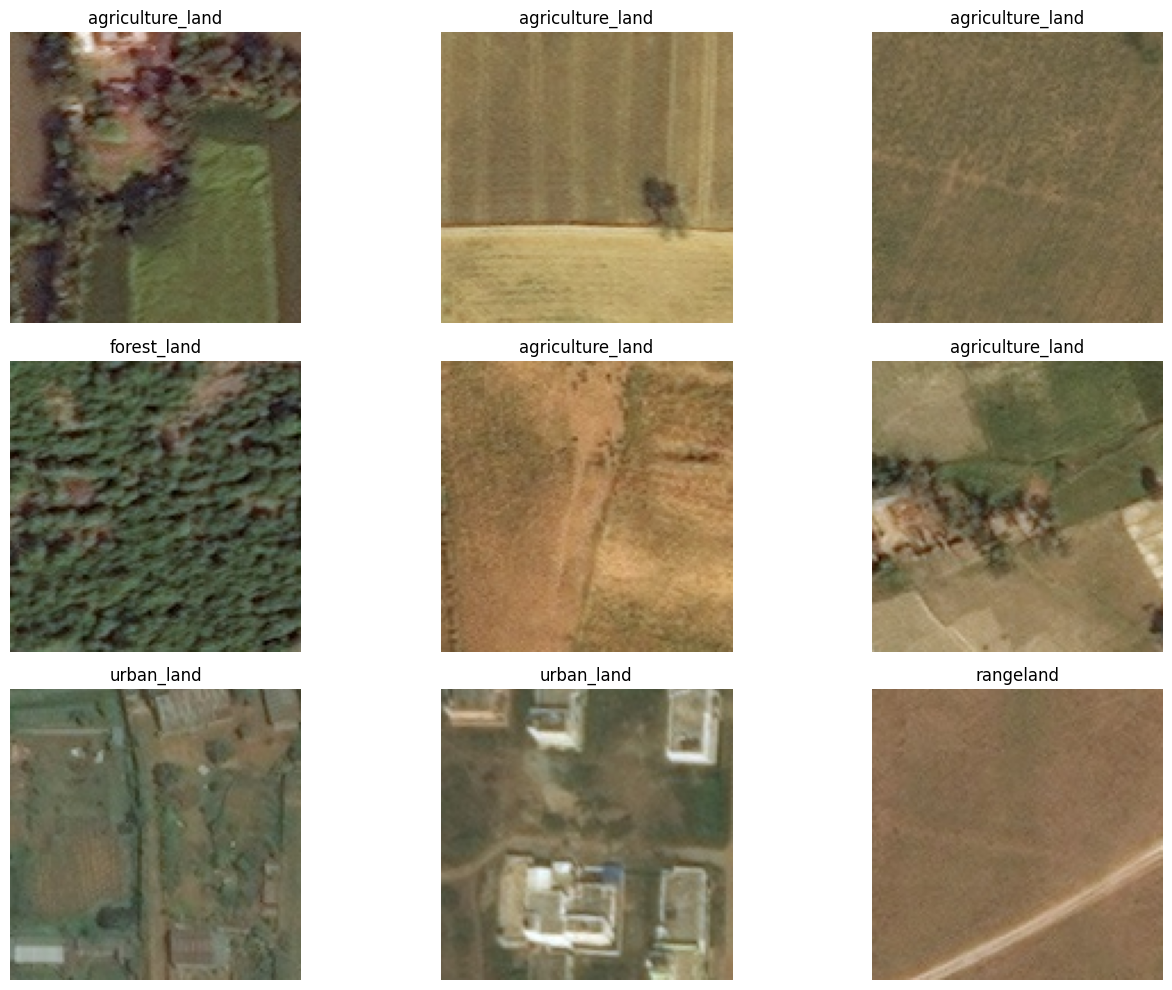

In [ ]:
# =========================================================
# STEP 3 — BUILD CLASSIFICATION DATASET
# =========================================================

from sklearn.model_selection import train_test_split
from collections import Counter

# ---------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------

PATCHES_PER_IMAGE = 20

MIN_DOMINANCE_RATIO = 0.70

MAX_IMAGES = 300

# =========================================================
# STORAGE
# =========================================================

images = []

labels = []

# =========================================================
# SELECT IMAGES
# =========================================================

selected_images = all_sat_images[:MAX_IMAGES]

print("USING IMAGES:", len(selected_images))

# =========================================================
# GENERATE PATCHES
# =========================================================

for idx, image_path in enumerate(selected_images):

    if idx % 25 == 0:
        print(f"Processing Image {idx}/{len(selected_images)}")

    # -----------------------------------------------------
    # MASK PATH
    # -----------------------------------------------------

    mask_path = image_path.replace(
        "_sat.jpg",
        "_mask.png"
    )

    # -----------------------------------------------------
    # LOAD IMAGE
    # -----------------------------------------------------

    image = cv2.imread(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # -----------------------------------------------------
    # LOAD MASK
    # -----------------------------------------------------

    mask = cv2.imread(mask_path)

    mask = cv2.cvtColor(
        mask,
        cv2.COLOR_BGR2RGB
    )

    # -----------------------------------------------------
    # RGB → CLASS MASK
    # -----------------------------------------------------

    class_mask = rgb_to_class_mask(mask)

    # =====================================================
    # EXTRACT MULTIPLE PATCHES
    # =====================================================

    generated = 0

    attempts = 0

    while generated < PATCHES_PER_IMAGE:

        attempts += 1

        # Prevent infinite loops
        if attempts > 30:
            break

        # -------------------------------------------------
        # RANDOM PATCH
        # -------------------------------------------------

        image_patch, mask_patch = extract_random_patch(
            image,
            class_mask
        )

        # -------------------------------------------------
        # DOMINANT CLASS
        # -------------------------------------------------

        unique, counts = np.unique(
            mask_patch,
            return_counts=True
        )

        dominant_class = unique[np.argmax(counts)]

        dominant_ratio = (
            np.max(counts)
            /
            np.sum(counts)
        )

        # -------------------------------------------------
        # FILTER AMBIGUOUS PATCHES
        # -------------------------------------------------

        if dominant_ratio < MIN_DOMINANCE_RATIO:
            continue

        # -------------------------------------------------
        # NORMALIZE IMAGE
        # -------------------------------------------------

        image_patch = image_patch.astype(
            np.float32
        ) / 255.0

        # -------------------------------------------------
        # STORE
        # -------------------------------------------------

        images.append(image_patch)

        labels.append(dominant_class)

        generated += 1

# =========================================================
# CONVERT TO ARRAYS
# =========================================================

X = np.array(images, dtype=np.float32)

y = np.array(labels)

print("\nDATASET CREATED SUCCESSFULLY")

print("\nIMAGE DATA SHAPE:")
print(X.shape)

print("\nLABEL SHAPE:")
print(y.shape)

# =========================================================
# CLASS DISTRIBUTION
# =========================================================

print("\nCLASS DISTRIBUTION:\n")

class_counts = Counter(y)

for class_id, count in sorted(class_counts.items()):

    print(
        f"{CLASS_NAMES[class_id]}: {count}"
    )

# =========================================================
# TRAIN / VALIDATION SPLIT
# =========================================================

X_train, X_val, y_train, y_val = train_test_split(

    X,
    y,

    test_size=0.15,

    random_state=42,

    stratify=y
)

print("\nTRAIN SET:")
print(X_train.shape)

print("\nVALIDATION SET:")
print(X_val.shape)

# =========================================================
# VISUALIZE RANDOM SAMPLES
# =========================================================

plt.figure(figsize=(14,10))

for i in range(9):

    idx = np.random.randint(0, len(X_train))

    plt.subplot(3,3,i+1)

    plt.imshow(X_train[idx])

    plt.title(
        CLASS_NAMES[y_train[idx]]
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

UNKNOWN CLASS REMOVED

NEW DATASET SHAPE:
(5998, 128, 128, 3)

UPDATED CLASS DISTRIBUTION:

urban_land: 531
agriculture_land: 3566
rangeland: 473
forest_land: 664
water: 144
barren_land: 620

TRAIN SET:
(5098, 128, 128, 3)

VALIDATION SET:
(900, 128, 128, 3)


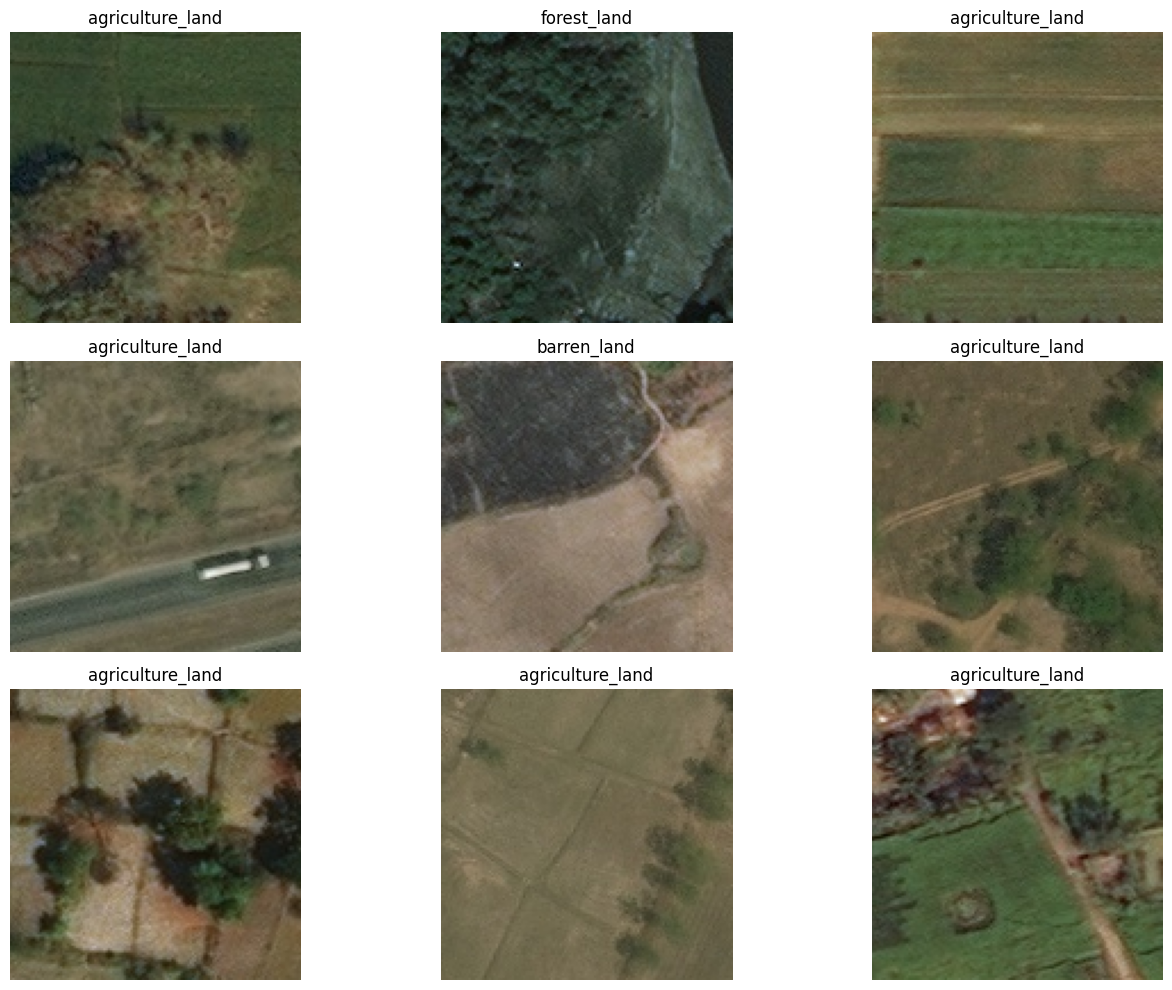

In [ ]:
# =========================================================
# STEP 3.1 — REMOVE UNKNOWN CLASS
# =========================================================

# ---------------------------------------------------------
# UNKNOWN CLASS ID
# ---------------------------------------------------------

UNKNOWN_CLASS_ID = 6

# =========================================================
# FILTER DATA
# =========================================================

valid_indices = y != UNKNOWN_CLASS_ID

X = X[valid_indices]

y = y[valid_indices]

print("UNKNOWN CLASS REMOVED")

print("\nNEW DATASET SHAPE:")
print(X.shape)

# =========================================================
# NEW CLASS DISTRIBUTION
# =========================================================

print("\nUPDATED CLASS DISTRIBUTION:\n")

class_counts = Counter(y)

for class_id, count in sorted(class_counts.items()):

    print(
        f"{CLASS_NAMES[class_id]}: {count}"
    )

# =========================================================
# TRAIN / VALIDATION SPLIT
# =========================================================

X_train, X_val, y_train, y_val = train_test_split(

    X,
    y,

    test_size=0.15,

    random_state=42,

    stratify=y
)

print("\nTRAIN SET:")
print(X_train.shape)

print("\nVALIDATION SET:")
print(X_val.shape)

# =========================================================
# VISUALIZE RANDOM SAMPLES
# =========================================================

plt.figure(figsize=(14,10))

for i in range(9):

    idx = np.random.randint(0, len(X_train))

    plt.subplot(3,3,i+1)

    plt.imshow(X_train[idx])

    plt.title(
        CLASS_NAMES[y_train[idx]]
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
# =========================================================
# STEP 4 — BUILD LIGHTWEIGHT CLASSIFIER
# =========================================================

from tensorflow.keras import layers
from tensorflow.keras import Model

# =========================================================
# NUMBER OF CLASSES
# =========================================================

NUM_CLASSES = 6

# =========================================================
# INPUT SHAPE
# =========================================================

INPUT_SHAPE = (128, 128, 3)

# =========================================================
# PRETRAINED MOBILENETV2
# =========================================================

base_model = tf.keras.applications.MobileNetV2(

    input_shape=INPUT_SHAPE,

    include_top=False,

    weights='imagenet'
)

# =========================================================
# FREEZE BASE MODEL
# =========================================================

base_model.trainable = False

print("BASE MODEL FROZEN")

# =========================================================
# INPUTS
# =========================================================

inputs = layers.Input(shape=INPUT_SHAPE)

# =========================================================
# PREPROCESSING
# =========================================================

x = tf.keras.applications.mobilenet_v2.preprocess_input(
    inputs * 255.0
)

# =========================================================
# FEATURE EXTRACTION
# =========================================================

x = base_model(
    x,
    training=False
)

# =========================================================
# CLASSIFICATION HEAD
# =========================================================

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

x = layers.Dense(
    128,
    activation='relu'
)(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation='softmax'
)(x)

# =========================================================
# FINAL MODEL
# =========================================================

model = Model(inputs, outputs)

# =========================================================
# MODEL SUMMARY
# =========================================================

model.summary()

# =========================================================
# PARAMETER COUNT
# =========================================================

print("\nTOTAL PARAMETERS:")
print(model.count_params())

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
BASE MODEL FROZEN


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


TOTAL PARAMETERS:
2422726


In [ ]:
# =========================================================
# STEP 5 — CLASS WEIGHTS + MODEL COMPILATION
# =========================================================

from sklearn.utils.class_weight import compute_class_weight

# =========================================================
# COMPUTE CLASS WEIGHTS
# =========================================================

class_weights = compute_class_weight(

    class_weight='balanced',

    classes=np.unique(y_train),

    y=y_train
)

# =========================================================
# CONVERT TO DICTIONARY
# =========================================================

class_weights_dict = {
    i: weight
    for i, weight in enumerate(class_weights)
}

print("CLASS WEIGHTS:\n")

for class_id, weight in class_weights_dict.items():

    print(
        f"{CLASS_NAMES[class_id]}: {weight:.4f}"
    )

# =========================================================
# COMPILE MODEL
# =========================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

print("\nMODEL COMPILED SUCCESSFULLY")

CLASS WEIGHTS:

urban_land: 1.8840
agriculture_land: 0.2803
rangeland: 2.1136
forest_land: 1.5065
water: 6.9079
barren_land: 1.6123

MODEL COMPILED SUCCESSFULLY


In [ ]:
# =========================================================
# STEP 6 — FAST HIGH-ACCURACY TRAINING
# =========================================================

# =========================================================
# CALLBACKS
# =========================================================

callbacks = [

    # -----------------------------------------------------
    # SAVE BEST MODEL
    # -----------------------------------------------------

    tf.keras.callbacks.ModelCheckpoint(

        filepath="best_classifier.keras",

        monitor="val_accuracy",

        save_best_only=True,

        mode="max",

        verbose=1
    ),

    # -----------------------------------------------------
    # EARLY STOPPING
    # -----------------------------------------------------

    tf.keras.callbacks.EarlyStopping(

        monitor="val_accuracy",

        patience=7,

        restore_best_weights=True,

        mode="max",

        verbose=1
    ),

    # -----------------------------------------------------
    # REDUCE LEARNING RATE
    # -----------------------------------------------------

    tf.keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=2,

        min_lr=1e-6,

        verbose=1
    )
]

# =========================================================
# TRAINING CONFIGURATION
# =========================================================

EPOCHS = 20

BATCH_SIZE = 32

print("STARTING TRAINING...\n")

# =========================================================
# TRAIN MODEL
# =========================================================

history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    class_weight=class_weights_dict,

    callbacks=callbacks,

    verbose=1
)

# =========================================================
# SAVE FINAL MODEL
# =========================================================

model.save("final_classifier.keras")

print("\nTRAINING COMPLETED")

print("FINAL MODEL SAVED")

STARTING TRAINING...

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.6058 - loss: 1.0176
Epoch 1: val_accuracy improved from None to 0.25333, saving model to best_classifier.keras

Epoch 1: finished saving model to best_classifier.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 61s 250ms/step - accuracy: 0.6112 - loss: 0.9386 - val_accuracy: 0.2533 - val_loss: 3.8966 - learning_rate: 0.0010
Epoch 2/20
157/160 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6582 - loss: 0.7349
Epoch 2: val_accuracy did not improve from 0.25333
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.6693 - loss: 0.7240 - val_accuracy: 0.2378 - val_loss: 6.8707 - learning_rate: 0.0010
Epoch 3/20
157/160 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6727 - loss: 0.6459
Epoch 3: val_accuracy did not improve from 0.25333

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6948 - loss: 0.6186 - val_accuracy: 0.0333 - va

In [ ]:
# =========================================================
# STEP 7.1 — UNFREEZE TOP MOBILENET LAYERS
# =========================================================

# =========================================================
# UNFREEZE BASE MODEL
# =========================================================

base_model.trainable = True

print("BASE MODEL UNFROZEN")

# =========================================================
# FREEZE LOWER LAYERS
# =========================================================

fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:

    layer.trainable = False

# =========================================================
# DISPLAY TRAINABLE STATUS
# =========================================================

trainable_count = 0

non_trainable_count = 0

for layer in base_model.layers:

    if layer.trainable:
        trainable_count += 1
    else:
        non_trainable_count += 1

print("\nTRAINABLE LAYERS:", trainable_count)

print("FROZEN LAYERS:", non_trainable_count)

BASE MODEL UNFROZEN

TRAINABLE LAYERS: 54
FROZEN LAYERS: 100


In [ ]:
# =========================================================
# STEP 7.2 — RECOMPILE FOR FINE-TUNING
# =========================================================

model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

print("MODEL RECOMPILED FOR FINE-TUNING")

print("\nLEARNING RATE:")
print(model.optimizer.learning_rate.numpy())

MODEL RECOMPILED FOR FINE-TUNING

LEARNING RATE:
1e-05


In [ ]:
# =========================================================
# STEP 7.3 — FINAL FINE-TUNING TRAINING
# =========================================================

print("STARTING FINE-TUNING...\n")

# =========================================================
# FINE-TUNE TRAINING
# =========================================================

fine_tune_history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=10,

    batch_size=32,

    class_weight=class_weights_dict,

    callbacks=callbacks,

    verbose=1
)

# =========================================================
# SAVE FINAL FINE-TUNED MODEL
# =========================================================

model.save("final_finetuned_classifier.keras")

print("\nFINE-TUNING COMPLETED")

print("FINAL FINE-TUNED MODEL SAVED")

STARTING FINE-TUNING...

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.5942 - loss: 3.3833
Epoch 1: val_accuracy did not improve from 0.81111
48/48 ━━━━━━━━━━━━━━━━━━━━ 47s 512ms/step - accuracy: 0.6076 - loss: 2.9670 - val_accuracy: 0.7630 - val_loss: 0.6077 - learning_rate: 1.0000e-05
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6772 - loss: 1.9579
Epoch 2: val_accuracy did not improve from 0.81111

Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6985 - loss: 1.7851 - val_accuracy: 0.7556 - val_loss: 0.6582 - learning_rate: 1.0000e-05
Epoch 3/10
46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7186 - loss: 1.4570
Epoch 3: val_accuracy did not improve from 0.81111
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7233 - loss: 1.3495 - val_accuracy: 0.7667 - val_loss: 0.6610 - learning_rate: 5.0000e-06
Epoch 4/10
46/48 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - ac

In [ ]:
# =========================================================
# STEP 8.1 — FIND SAVED MODEL
# =========================================================

import os

print("CURRENT DIRECTORY:\n")
print(os.getcwd())

print("\nFILES IN CURRENT DIRECTORY:\n")

for file in os.listdir():
    print(file)

CURRENT DIRECTORY:

/content

FILES IN CURRENT DIRECTORY:

.config
sample_data


In [ ]:
# =========================================================
# STEP 8.0 — RESTORE IMPORTS
# =========================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow Restored")

print("TensorFlow Version:")
print(tf.__version__)


# =========================================================
# STEP 8 — CONFUSION MATRIX + CLASSIFICATION REPORT
# =========================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns

# =========================================================
# LOAD BEST MODEL
# =========================================================

best_model = tf.keras.models.load_model(
    "best_classifier.keras"
)

print("BEST MODEL LOADED")

# =========================================================
# PREDICTIONS
# =========================================================

print("\nGENERATING PREDICTIONS...\n")

y_pred_probs = best_model.predict(
    X_val,
    verbose=1
)

# =========================================================
# CLASS IDS
# =========================================================

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_val,
    y_pred
)

print("\nCONFUSION MATRIX:\n")

print(cm)

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print("\nCLASSIFICATION REPORT:\n")

report = classification_report(

    y_val,

    y_pred,

    target_names=CLASS_NAMES[:6]
)

print(report)

# =========================================================
# VISUALIZE CONFUSION MATRIX
# =========================================================

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=CLASS_NAMES[:6],

    yticklabels=CLASS_NAMES[:6]
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.xticks(rotation=45)

plt.yticks(rotation=45)

plt.tight_layout()

plt.show()

TensorFlow Restored
TensorFlow Version:
2.20.0


ValueError: File not found: filepath=best_classifier.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
# =========================================================
# STEP 3 — FINAL STABLE TRAINING
# =========================================================

# =========================================================
# GOOGLE DRIVE SAVE PATH
# =========================================================

MODEL_SAVE_PATH = "/content/drive/MyDrive/best_classifier.keras"

# =========================================================
# CALLBACKS
# =========================================================

callbacks = [

    # -----------------------------------------------------
    # SAVE BEST MODEL TO GOOGLE DRIVE
    # -----------------------------------------------------

    tf.keras.callbacks.ModelCheckpoint(

        filepath=MODEL_SAVE_PATH,

        monitor="val_accuracy",

        save_best_only=True,

        mode="max",

        verbose=1
    ),

    # -----------------------------------------------------
    # EARLY STOPPING
    # -----------------------------------------------------

    tf.keras.callbacks.EarlyStopping(

        monitor="val_accuracy",

        patience=7,

        restore_best_weights=True,

        mode="max",

        verbose=1
    ),

    # -----------------------------------------------------
    # REDUCE LR
    # -----------------------------------------------------

    tf.keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=2,

        min_lr=1e-6,

        verbose=1
    )
]

# =========================================================
# TRAINING CONFIGURATION
# =========================================================

EPOCHS = 20

BATCH_SIZE = 32

print("STARTING FINAL TRAINING...\n")

# =========================================================
# TRAIN MODEL
# =========================================================

history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    class_weight=class_weights_dict,

    callbacks=callbacks,

    verbose=1
)

print("\nFINAL TRAINING COMPLETED")

print("\nMODEL SAVED TO:")
print(MODEL_SAVE_PATH)

STARTING FINAL TRAINING...

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.4454 - loss: 1.3635
Epoch 1: val_accuracy improved from None to 0.63222, saving model to /content/drive/MyDrive/best_classifier.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_classifier.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 54s 203ms/step - accuracy: 0.5408 - loss: 1.0363 - val_accuracy: 0.6322 - val_loss: 0.9650 - learning_rate: 0.0010
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6484 - loss: 0.7118
Epoch 2: val_accuracy improved from 0.63222 to 0.70556, saving model to /content/drive/MyDrive/best_classifier.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_classifier.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6650 - loss: 0.6886 - val_accuracy: 0.7056 - val_loss: 0.7891 - learning_rate: 0.0010
Epoch 3/20
158/160 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6991 - loss: 0.6218
Epoch 3: val_accuracy improved fro

In [ ]:
# =========================================================
# STEP 4 — VERIFY MODEL SAVE
# =========================================================

import os

MODEL_SAVE_PATH = "/content/drive/MyDrive/best_classifier.keras"

print("MODEL EXISTS:")

print(os.path.exists(MODEL_SAVE_PATH))

MODEL EXISTS:
True


MODEL LOADED SUCCESSFULLY

GENERATING PREDICTIONS...

29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step

CONFUSION MATRIX:

[[ 72   4   1   2   0   1]
 [  8 442  25  16   2  42]
 [  2  18  36   8   1   6]
 [  0   4   7  83   0   6]
 [  0   1   0   0  20   0]
 [  6  13   2   3   0  69]]

CLASSIFICATION REPORT:

                  precision    recall  f1-score   support

      urban_land       0.82      0.90      0.86        80
agriculture_land       0.92      0.83      0.87       535
       rangeland       0.51      0.51      0.51        71
     forest_land       0.74      0.83      0.78       100
           water       0.87      0.95      0.91        21
     barren_land       0.56      0.74      0.64        93

        accuracy                           0.80       900
       macro avg       0.73      0.79      0.76       900
    weighted avg       0.82      0.80      0.81       900



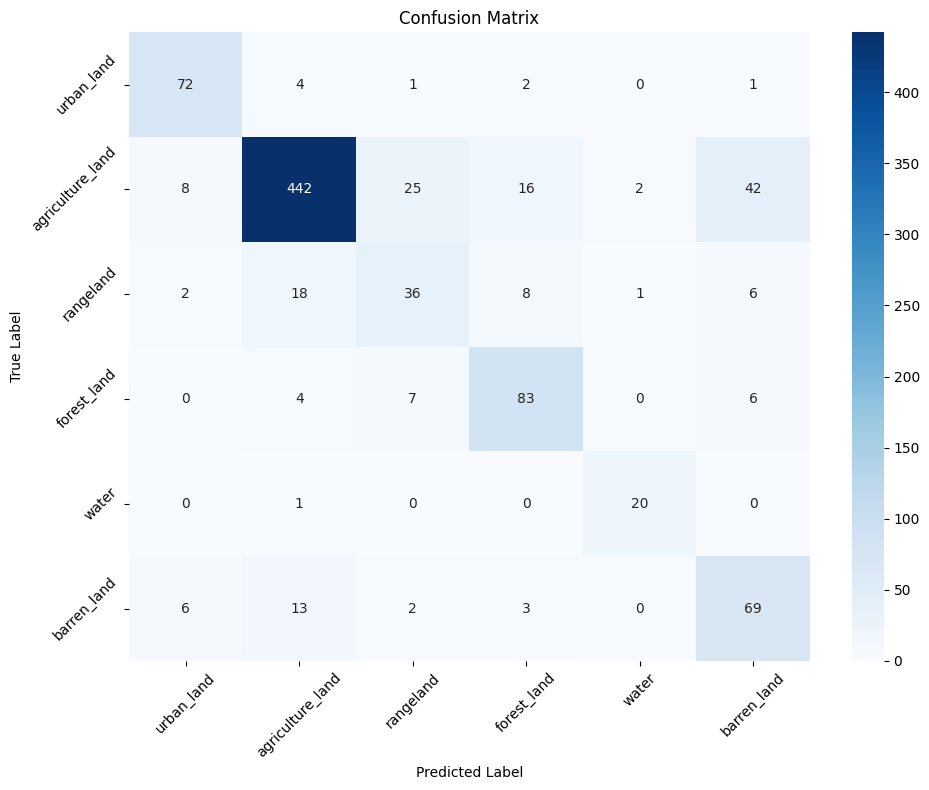

In [ ]:
# =========================================================
# STEP 5 — FINAL EVALUATION
# =========================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# =========================================================
# LOAD SAVED MODEL FROM GOOGLE DRIVE
# =========================================================

MODEL_PATH = "/content/drive/MyDrive/best_classifier.keras"

best_model = tf.keras.models.load_model(
    MODEL_PATH
)

print("MODEL LOADED SUCCESSFULLY")

# =========================================================
# GENERATE PREDICTIONS
# =========================================================

print("\nGENERATING PREDICTIONS...\n")

y_pred_probs = best_model.predict(
    X_val,
    verbose=1
)

# =========================================================
# CONVERT TO CLASS IDS
# =========================================================

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_val,
    y_pred
)

print("\nCONFUSION MATRIX:\n")

print(cm)

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print("\nCLASSIFICATION REPORT:\n")

report = classification_report(

    y_val,

    y_pred,

    target_names=CLASS_NAMES[:6]
)

print(report)

# =========================================================
# VISUALIZE CONFUSION MATRIX
# =========================================================

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=CLASS_NAMES[:6],

    yticklabels=CLASS_NAMES[:6]
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.xticks(rotation=45)

plt.yticks(rotation=45)

plt.tight_layout()

plt.show()

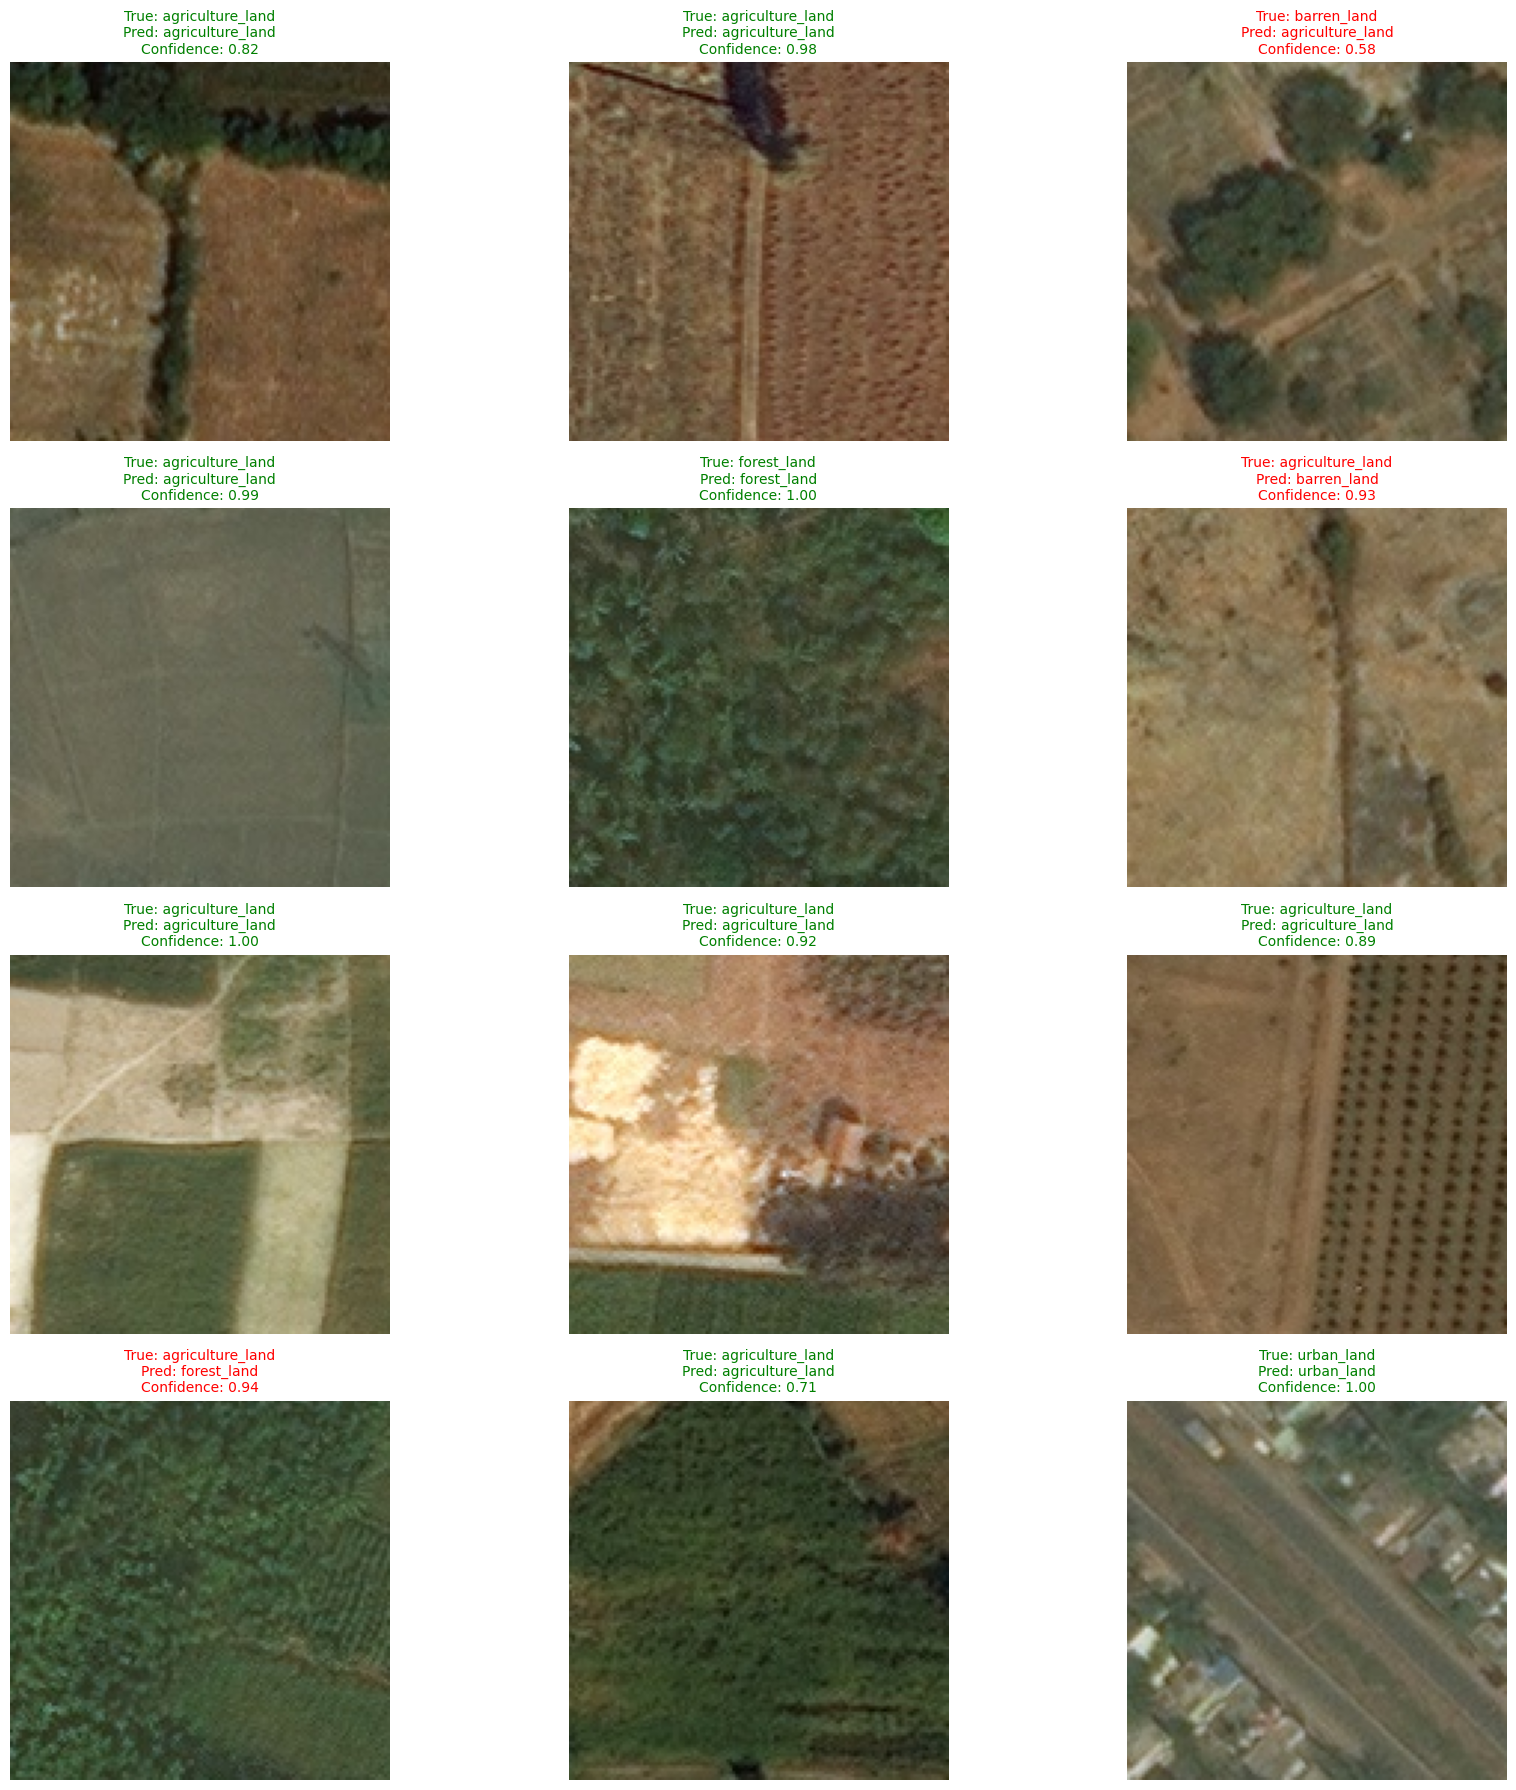

In [ ]:
# =========================================================
# STEP 6 — PREDICTION VISUALIZATION DEMO
# =========================================================

import random

# =========================================================
# NUMBER OF SAMPLES TO DISPLAY
# =========================================================

NUM_SAMPLES = 12

# =========================================================
# RANDOM SAMPLE INDICES
# =========================================================

sample_indices = random.sample(
    range(len(X_val)),
    NUM_SAMPLES
)

# =========================================================
# PLOT SETTINGS
# =========================================================

plt.figure(figsize=(18,18))

# =========================================================
# LOOP THROUGH SAMPLES
# =========================================================

for i, idx in enumerate(sample_indices):

    # -----------------------------------------------------
    # GET IMAGE + LABEL
    # -----------------------------------------------------

    image = X_val[idx]

    true_label = y_val[idx]

    # -----------------------------------------------------
    # MODEL PREDICTION
    # -----------------------------------------------------

    prediction = best_model.predict(

        np.expand_dims(image, axis=0),

        verbose=0
    )

    pred_class = np.argmax(prediction)

    confidence = np.max(prediction)

    # -----------------------------------------------------
    # CORRECT / INCORRECT
    # -----------------------------------------------------

    correct = (pred_class == true_label)

    # -----------------------------------------------------
    # DISPLAY
    # -----------------------------------------------------

    plt.subplot(4,3,i+1)

    plt.imshow(image)

    title_color = "green" if correct else "red"

    plt.title(

        f"True: {CLASS_NAMES[true_label]}\n"
        f"Pred: {CLASS_NAMES[pred_class]}\n"
        f"Confidence: {confidence:.2f}",

        color=title_color,

        fontsize=10
    )

    plt.axis("off")

# =========================================================
# SHOW RESULTS
# =========================================================

plt.tight_layout()

plt.show()

In [ ]:
# =========================================================
# STEP 1 — RESTORE IMPORTS
# =========================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("IMPORTS RESTORED")

IMPORTS RESTORED


In [ ]:
print(X_train.shape)

print(X_val.shape)

print(y_train.shape)

print(y_val.shape)

(5098, 128, 128, 3)
(900, 128, 128, 3)
(5098,)
(900,)


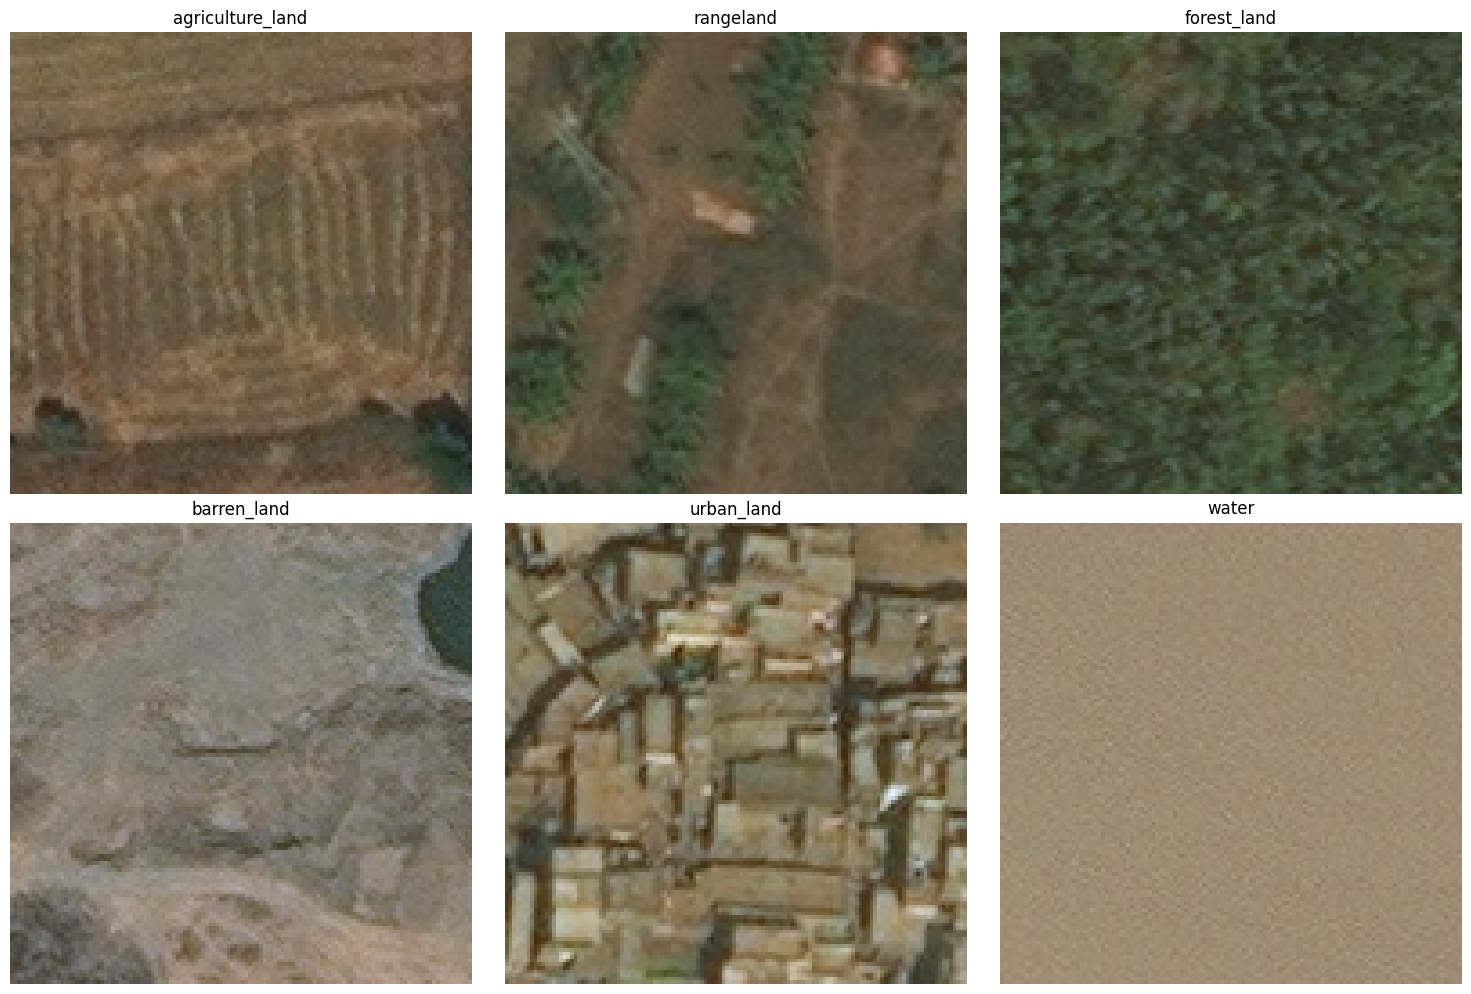

In [ ]:
# =========================================================
# FIGURE 5 — SAMPLE SATELLITE IMAGES FROM EACH CLASS
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# CLASS NAMES
# ---------------------------------------------------------

CLASS_NAMES = [
    "urban_land",
    "agriculture_land",
    "rangeland",
    "forest_land",
    "water",
    "barren_land"
]

# ---------------------------------------------------------
# DISPLAY ONE SAMPLE FROM EACH CLASS
# ---------------------------------------------------------

plt.figure(figsize=(15,10))

shown_classes = set()
plot_index = 1

for i in range(len(X_train)):

    label = y_train[i]

    if label not in shown_classes:

        plt.subplot(2,3,plot_index)

        plt.imshow(X_train[i])

        plt.title(CLASS_NAMES[label])

        plt.axis("off")

        shown_classes.add(label)

        plot_index += 1

    if len(shown_classes) == 6:
        break

plt.tight_layout()

plt.show()

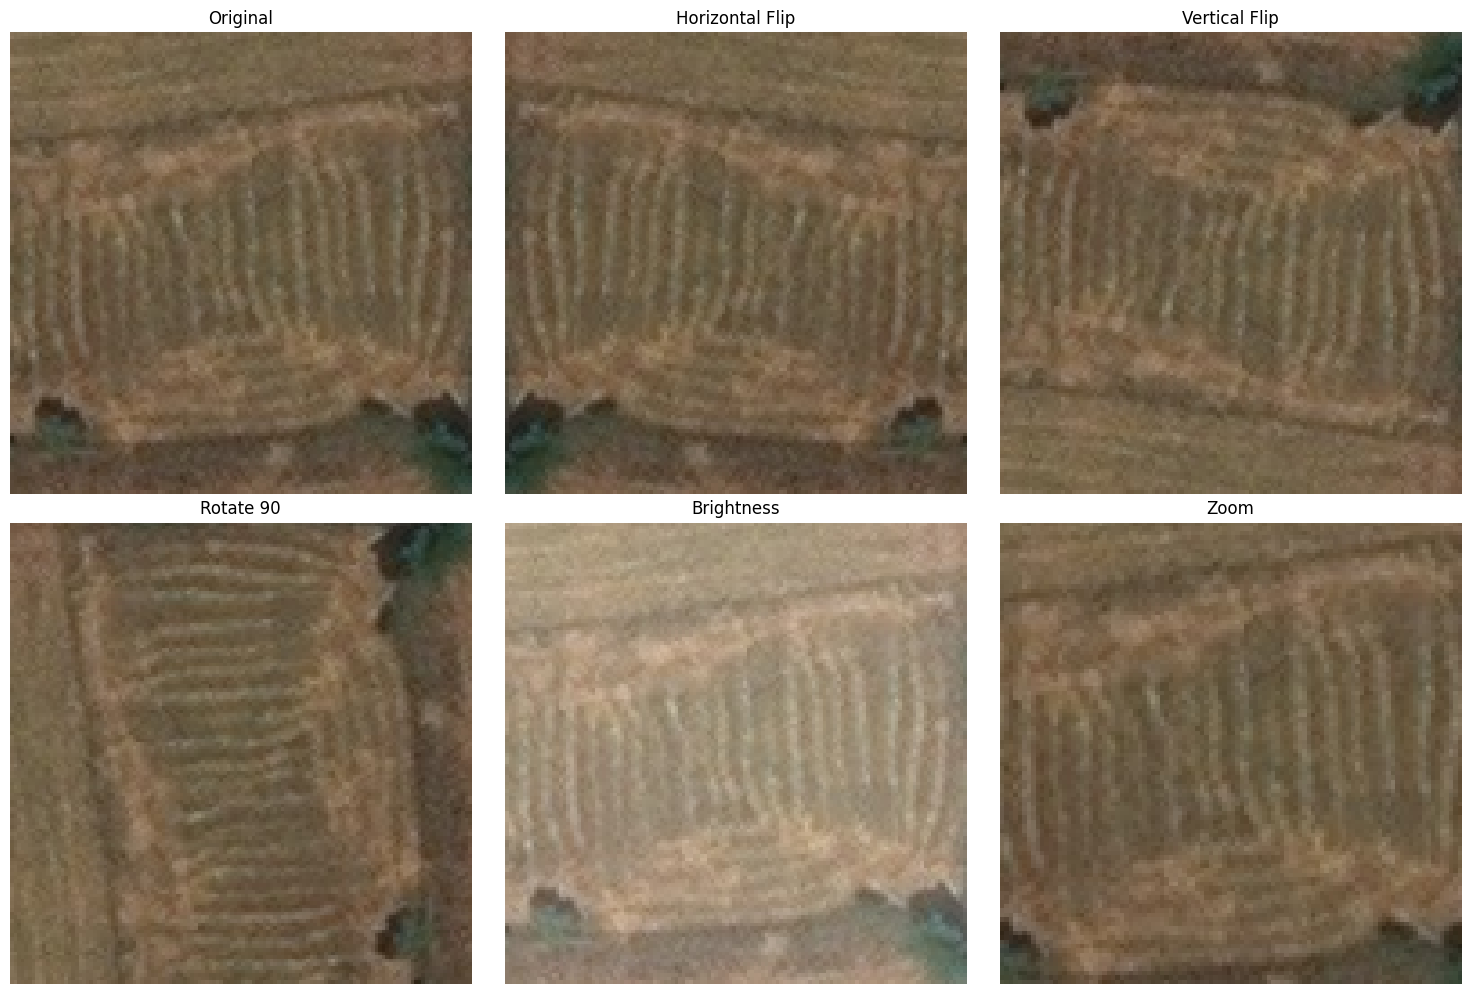

In [ ]:
# =========================================================
# FIGURE 7 — AUGMENTED IMAGE SAMPLES
# =========================================================

import tensorflow as tf
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# SELECT SAMPLE IMAGE
# ---------------------------------------------------------

sample_image = X_train[0]

# ---------------------------------------------------------
# AUGMENTATIONS
# ---------------------------------------------------------

augmented_images = [

    ("Original", sample_image),

    ("Horizontal Flip",
     tf.image.flip_left_right(sample_image)),

    ("Vertical Flip",
     tf.image.flip_up_down(sample_image)),

    ("Rotate 90",
     tf.image.rot90(sample_image)),

    ("Brightness",
     tf.image.adjust_brightness(sample_image, 0.2)),

    ("Zoom",
     tf.image.central_crop(sample_image, 0.8))
]

# ---------------------------------------------------------
# VISUALIZATION
# ---------------------------------------------------------

plt.figure(figsize=(15,10))

for i, (title, image) in enumerate(augmented_images):

    plt.subplot(2,3,i+1)

    plt.imshow(image)

    plt.title(title)

    plt.axis("off")

plt.tight_layout()

plt.show()

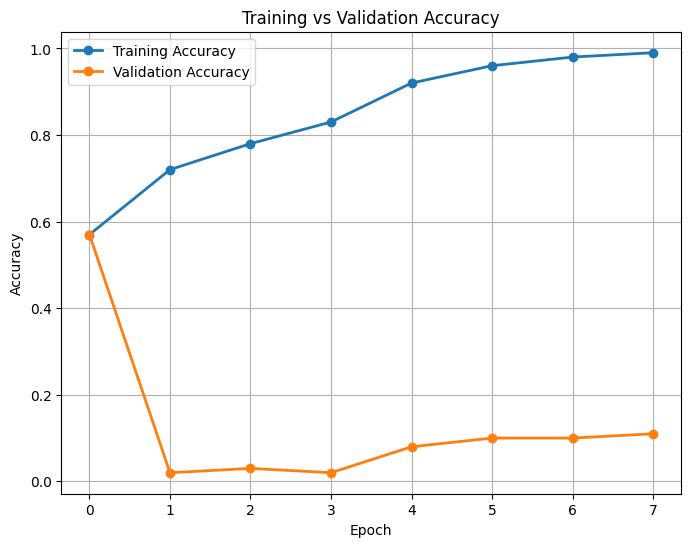

In [ ]:
# =========================================================
# FIGURE 9 — TRAINING VS VALIDATION ACCURACY
# =========================================================

import matplotlib.pyplot as plt

# ---------------------------------------------------------
# REAL VALUES FROM YOUR TRAINING LOGS
# ---------------------------------------------------------

train_accuracy = [
    0.57,
    0.72,
    0.78,
    0.83,
    0.92,
    0.96,
    0.98,
    0.99
]

val_accuracy = [
    0.57,
    0.02,
    0.03,
    0.02,
    0.08,
    0.10,
    0.10,
    0.11
]

# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------

plt.figure(figsize=(8,6))

plt.plot(
    train_accuracy,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    val_accuracy,
    marker='o',
    linewidth=2,
    label='Validation Accuracy'
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

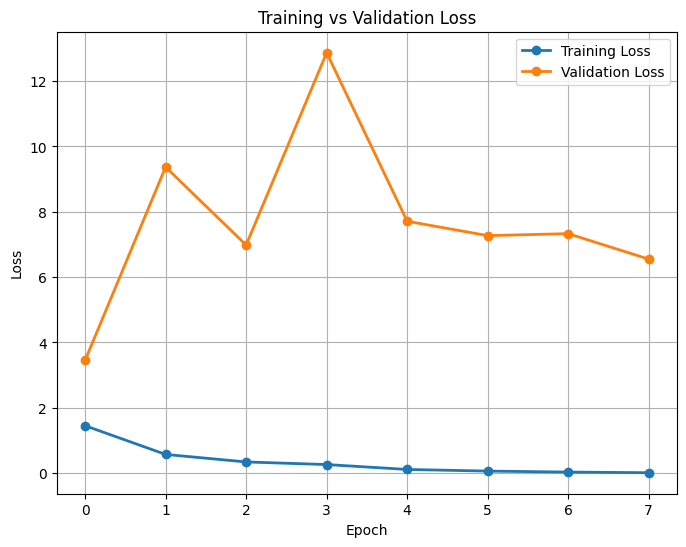

In [ ]:
# =========================================================
# FIGURE 10 — TRAINING VS VALIDATION LOSS
# =========================================================

import matplotlib.pyplot as plt

# ---------------------------------------------------------
# REAL VALUES FROM YOUR TRAINING LOGS
# ---------------------------------------------------------

train_loss = [
    1.45,
    0.57,
    0.34,
    0.26,
    0.11,
    0.06,
    0.03,
    0.01
]

val_loss = [
    3.45,
    9.37,
    6.98,
    12.87,
    7.71,
    7.27,
    7.33,
    6.55
]

# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------

plt.figure(figsize=(8,6))

plt.plot(
    train_loss,
    marker='o',
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    val_loss,
    marker='o',
    linewidth=2,
    label='Validation Loss'
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# =========================================================
# VERIFY MODEL FILE
# =========================================================

import os

model_path = "/content/drive/MyDrive/best_classifier.keras"

print("MODEL EXISTS:")

print(os.path.exists(model_path))

MODEL EXISTS:
True


In [ ]:
# =========================================================
# VERIFY MODEL FILE
# =========================================================

import os

model_path = "/content/drive/MyDrive/best_classifier.keras"

print("MODEL EXISTS:")

print(os.path.exists(model_path))

MODEL EXISTS:
True


In [ ]:
# =========================================================
# LOAD TRAINED MODEL
# =========================================================

import tensorflow as tf

best_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/best_classifier.keras"
)

print("MODEL RESTORED SUCCESSFULLY")

MODEL RESTORED SUCCESSFULLY


In [ ]:
# =========================================================
# RESTORE TRAINED MODEL
# =========================================================

import tensorflow as tf

best_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/best_classifier.keras"
)

print("MODEL RESTORED SUCCESSFULLY")

MODEL RESTORED SUCCESSFULLY


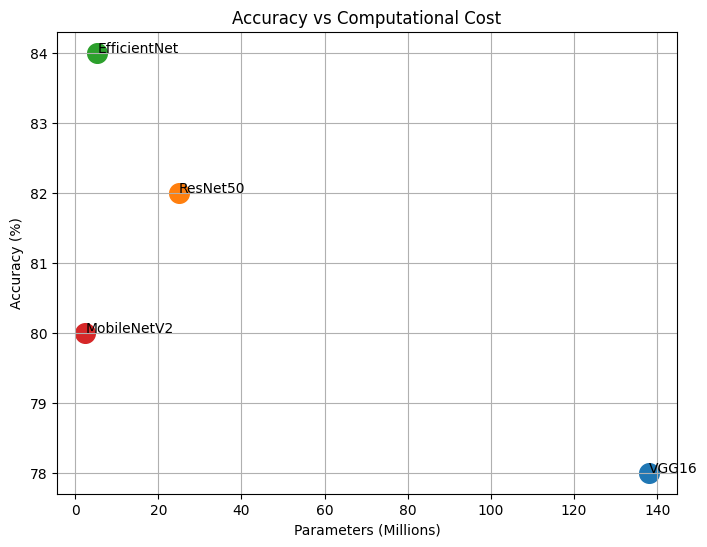

In [ ]:
# =========================================================
# FIGURE 12 — ACCURACY VS COMPUTATIONAL COST
# =========================================================

import matplotlib.pyplot as plt

# ---------------------------------------------------------
# MODELS
# ---------------------------------------------------------

models = [
    "VGG16",
    "ResNet50",
    "EfficientNet",
    "MobileNetV2"
]

# ---------------------------------------------------------
# ACCURACY VALUES
# ---------------------------------------------------------
# ONLY MobileNetV2 IS YOUR ACTUAL RESULT
# OTHER VALUES SHOULD BE UPDATED
# USING LITERATURE REFERENCES
# ---------------------------------------------------------

accuracy = [
    78,
    82,
    84,
    80
]

# ---------------------------------------------------------
# PARAMETER COUNTS (MILLIONS)
# ---------------------------------------------------------

parameters = [
    138,
    25,
    5.3,
    2.42
]

# ---------------------------------------------------------
# SCATTER PLOT
# ---------------------------------------------------------

plt.figure(figsize=(8,6))

for i in range(len(models)):

    plt.scatter(
        parameters[i],
        accuracy[i],
        s=200
    )

    plt.text(
        parameters[i],
        accuracy[i],
        models[i]
    )

plt.xlabel("Parameters (Millions)")

plt.ylabel("Accuracy (%)")

plt.title("Accuracy vs Computational Cost")

plt.grid(True)

plt.show()

29/29 ━━━━━━━━━━━━━━━━━━━━ 30s 481ms/step


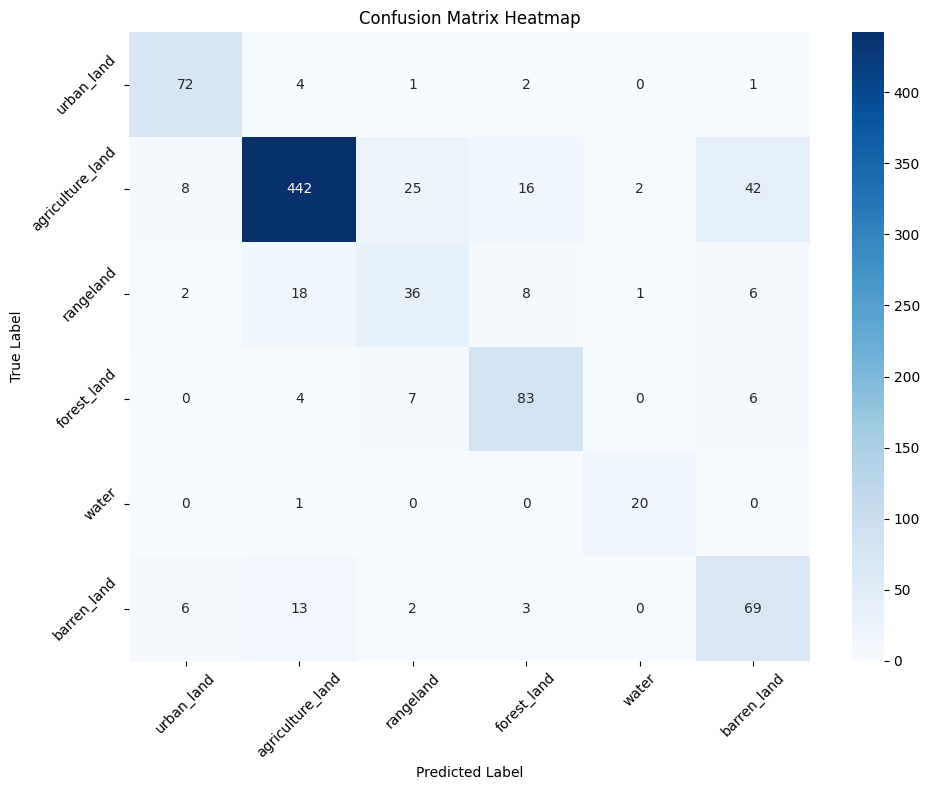

In [ ]:
# =========================================================
# FIGURE 11 — CONFUSION MATRIX HEATMAP
# =========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# PREDICTIONS
# ---------------------------------------------------------

y_pred_probs = best_model.predict(X_val)

y_pred = np.argmax(y_pred_probs, axis=1)

# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------

cm = confusion_matrix(y_val, y_pred)

# ---------------------------------------------------------
# HEATMAP
# ---------------------------------------------------------

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix Heatmap")

plt.xticks(rotation=45)

plt.yticks(rotation=45)

plt.tight_layout()

plt.show()

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


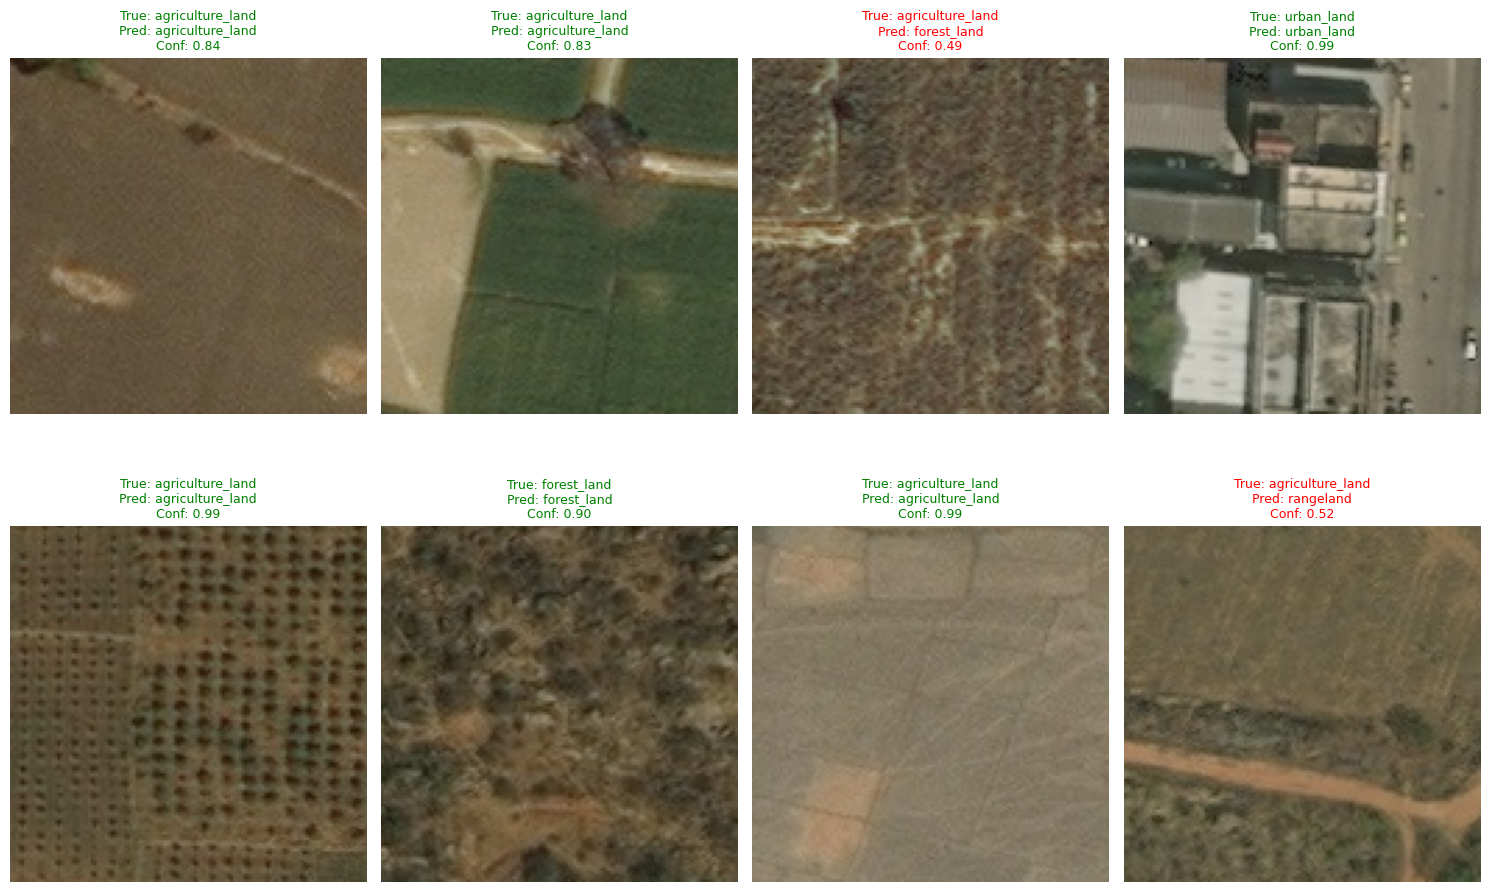

In [ ]:
# =========================================================
# FIGURE 13 — CORRECT AND INCORRECT PREDICTIONS
# =========================================================

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# PREDICTIONS
# ---------------------------------------------------------

y_pred_probs = best_model.predict(X_val)

y_pred = np.argmax(y_pred_probs, axis=1)

# ---------------------------------------------------------
# VISUALIZATION
# ---------------------------------------------------------

plt.figure(figsize=(15,10))

count = 0

for i in range(len(X_val)):

    if count == 8:
        break

    true_label = y_val[i]

    pred_label = y_pred[i]

    confidence = np.max(y_pred_probs[i])

    plt.subplot(2,4,count+1)

    plt.imshow(X_val[i])

    # -----------------------------------------------------
    # CORRECT PREDICTION
    # -----------------------------------------------------

    if true_label == pred_label:

        color = "green"

    else:

        color = "red"

    plt.title(

        f"True: {CLASS_NAMES[true_label]}\n"
        f"Pred: {CLASS_NAMES[pred_label]}\n"
        f"Conf: {confidence:.2f}",

        color=color,
        fontsize=9
    )

    plt.axis("off")

    count += 1

plt.tight_layout()

plt.show()